In [4]:
import pandas as pd
import numpy as np

data = pd.read_csv('/Users/arminas/Downloads/Crime_Data_from_2020_to_2024.csv')

In [5]:
data.shape
data.dtypes

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object

In [6]:
missing = data.isnull().sum()
missing.sort_index


<bound method Series.sort_index of DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151598
Vict Age                0
Vict Sex           144631
Vict Descent       144643
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677678
Weapon Desc        677678
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           935740
Crm Cd 3          1002580
Crm Cd 4          1004830
LOCATION                0
Cross Street       850666
LAT                     0
LON                     0
dtype: int64>

In [ ]:
data = data.drop(columns=[
    'Crm Cd 1',
    'Crm Cd 2',
    'Crm Cd 3',
    'Crm Cd 4',
    'Mocodes',
    'Weapon Used Cd'
])

data['Weapon Desc'] = data['Weapon Desc'].fillna('None')
data['Vict Sex'] = data['Vict Sex'].fillna('Unknown')
data['Vict Descent'] = data['Vict Descent'].fillna('Unknown')
data['Premis Desc'] = data['Premis Desc'].fillna('Unknown')

data = data.dropna(subset=['Premis Cd', 'Status'])
data

KeyError: "['Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Mocodes', 'Weapon Used Cd'] not found in axis"

In [8]:
print(data['Crm Cd Desc'].unique())

['THEFT OF IDENTITY' 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT'
 'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)'
 'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)'
 'CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)'
 'VEHICLE - STOLEN' 'BURGLARY' 'BURGLARY FROM VEHICLE'
 'THEFT PLAIN - PETTY ($950 & UNDER)' 'INTIMATE PARTNER - SIMPLE ASSAULT'
 'BATTERY - SIMPLE ASSAULT' 'VANDALISM - MISDEAMEANOR ($399 OR UNDER)'
 'VEHICLE - ATTEMPT STOLEN'
 'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)' 'ROBBERY'
 'FIREARMS RESTRAINING ORDER (FIREARMS RO)' 'BIKE - STOLEN'
 'EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)'
 'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT'
 'CRIMINAL THREATS - NO WEAPON DISPLAYED'
 'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD'
 'BATTERY WITH SEXUAL CONTACT' 'LETTERS, LEWD  -  TELEPHONE CALLS, LEWD'
 'VIOLATION OF COURT ORDER' 'ARSON' 'VIOLATION OF RESTRAINING ORDER'
 'THEFT, PERSON' 'CONTEMPT OF COURT'
 'INTIMATE PARTNER - AGGRAVATED ASSAU

In [9]:
code_map = data.groupby('Crm Cd')['Crm Cd Desc'].first().sort_index()
print(code_map.to_string())

Crm Cd
110                                    CRIMINAL HOMICIDE
113                              MANSLAUGHTER, NEGLIGENT
121                                       RAPE, FORCIBLE
122                                      RAPE, ATTEMPTED
210                                              ROBBERY
220                                    ATTEMPTED ROBBERY
230       ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT
231         ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER
235          CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT
236                INTIMATE PARTNER - AGGRAVATED ASSAULT
237                       CHILD NEGLECT (SEE 300 W.I.C.)
250     SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT
251                    SHOTS FIRED AT INHABITED DWELLING
310                                             BURGLARY
320                                  BURGLARY, ATTEMPTED
330                                BURGLARY FROM VEHICLE
331    THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...
341    THEFT-GRAND ($950

In [10]:
data['crime_category'] = pd.cut(
    data['Crm Cd'],
    bins=[109, 123, 260, 325, 509, 522, 700, 900, 957],
    labels=[
        'Homicide & Rape',      # 110-122
        'Robbery & Assault',    # 210-251
        'Burglary',             # 310-320
        'Theft',                # 330-509
        'Vehicle Crime',        # 510-520
        'Arson & Other',        # 522-700
        'Vandalism & Weapons',  # 700-900
        'Sex Crime & Misc'      # 900-956
    ]
)

print(data.groupby('crime_category')['Crm Cd Desc'].unique().to_string())


crime_category
Homicide & Rape        [RAPE, ATTEMPTED, RAPE, FORCIBLE, CRIMINAL HOM...
Robbery & Assault      [ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAUL...
Burglary                                 [BURGLARY, BURGLARY, ATTEMPTED]
Theft                  [THEFT OF IDENTITY, THEFT FROM MOTOR VEHICLE -...
Vehicle Crime          [VEHICLE - STOLEN, VEHICLE - ATTEMPT STOLEN, V...
Arson & Other          [INTIMATE PARTNER - SIMPLE ASSAULT, BATTERY - ...
Vandalism & Weapons    [CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10...
Sex Crime & Misc       [FIREARMS RESTRAINING ORDER (FIREARMS RO), CRI...


/var/folders/3g/p0dltljx40g8h0d492jf4qch0000gn/T/ipykernel_73245/855825951.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('crime_category')['Crm Cd Desc'].unique().to_string())


### New column added: 
## 'crime_category'

To simplify analysis, crime descriptions were grouped into 8 broader categories.

This approach is more robust than keyword matching


| Range | Category | Examples |
|-------|----------|----------------|
| 110 – 122 | Homicide & Rape | Criminal Homicide, Manslaughter, Forcible Rape |
| 123 – 260 | Robbery & Assault | Robbery, Aggravated Assault, Shots Fired |
| 261 – 325 | Burglary | Burglary, Attempted Burglary |
| 326 – 509 | Theft | Grand Theft, Shoplifting, Purse Snatching, Identity Theft |
| 510 – 522 | Vehicle Crime | Vehicle Stolen, Attempted Vehicle Theft |
| 523 – 700 | Arson & Other Property | Arson, Trespassing |
| 701 – 900 | Vandalism & Weapons | Vandalism, Weapon Violations |
| 901 – 956 | Sex Crime & Misc | Lewd Conduct, Contributing, Threatening Calls |


In [18]:
print(data['Vict Age'].min(), data['Vict Age'].max())
print((data['LAT'] == 0).sum())
print(data['Vict Sex'].unique())
print(data[['Date Rptd', 'DATE OCC']].dtypes)

-4 120
2240
['M' 'F' 'Unknown' 'X' 'H' '-']
Date Rptd    object
DATE OCC     object
dtype: object


In [23]:
data = data[(data['Vict Age'] >= 0) & (data['Vict Age'] <= 100)]
print(data['Vict Age'].min(), data['Vict Age'].max())

data = data[(data['LAT'] != 0) & (data['LON'] != 0)]
print((data['LAT'] == 0).sum())
print((data['LON'] == 0).sum())

def clean_sex(sex):
    if sex == 'M' or sex == "F":
        return sex
    else:
        return 'Unknown'
    
data['Vict Sex'] = data['Vict Sex'].apply(clean_sex)
print(data['Vict Sex'].unique())

data['Date Rptd'] = pd.to_datetime(data['Date Rptd'])
data['DATE OCC'] = pd.to_datetime(data['DATE OCC'])
print(data[['Date Rptd', 'DATE OCC']].dtypes)


0 99
0
0
['M' 'F' 'Unknown']
Date Rptd    datetime64[ns]
DATE OCC     datetime64[ns]
dtype: object


In [26]:
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
print(data.columns)

Index(['dr_no', 'date_rptd', 'date_occ', 'time_occ', 'area', 'area_name',
       'rpt_dist_no', 'part_1-2', 'crm_cd', 'crm_cd_desc', 'vict_age',
       'vict_sex', 'vict_descent', 'premis_cd', 'premis_desc', 'weapon_desc',
       'status', 'status_desc', 'location', 'cross_street', 'lat', 'lon',
       'crime_category'],
      dtype='object')


In [36]:
data.isnull().sum()

dr_no             0
date_rptd         0
date_occ          0
time_occ          0
area              0
area_name         0
rpt_dist_no       0
part_1-2          0
crm_cd            0
crm_cd_desc       0
vict_age          0
vict_sex          0
vict_descent      0
premis_cd         0
premis_desc       0
weapon_desc       0
status            0
status_desc       0
location          0
lat               0
lon               0
crime_category    0
dtype: int64

In [40]:
print(data['date_occ'].min(), data['date_occ'].max())

2020-01-01 00:00:00 2024-12-30 00:00:00


## Column names

### Record
- **`dr_no`** — Official file number (2-digit year + area ID + 5 digits)
- **`part_1-2`** — Crime classification (1 = more serious, 2 = less serious)

### Time & Date
- **`date_rptd`** — Date the crime was reported (MM/DD/YYYY)
- **`date_occ`** — Date the crime occurred (MM/DD/YYYY)
- **`time_occ`** — Time of occurrence (24-hour military time)

### Location
- **`area`** — LAPD geographic area ID (1–21)
- **`area_name`** — Name of the geographic area
- **`rpt_dist_no`** — Four-digit sub-area code within a geographic area
- **`location`** — Street address rounded to nearest hundred block (anonymised)
- **`lat`** / **`lon`** — Latitude / Longitude

### Crime
- **`crm_cd`** — Primary crime code
- **`crm_cd_desc`** — Description of the primary crime code
- **`crime_category`** — Grouped crime category derived from `crm_cd`

### Victim
- **`vict_age`** — Two-character numeric
- **`vict_sex`** — `F` Female · `M` Male · `Unknown` Unknown
- **`vict_descent`** — `A` Other Asian · `B` Black · `C` Chinese · `D` Cambodian · `F` Filipino · `G` Guamanian · `H` Hispanic/Latin/Mexican · `I` American Indian/Alaskan Native · `J` Japanese · `K` Korean · `L` Laotian · `O` Other · `P` Pacific Islander · `S` Samoan · `U` Hawaiian · `V` Vietnamese · `W` White · `X` Unknown · `Z` Asian Indian

### Premise
- **`premis_cd`** — Code for the type of structure, vehicle, or location
- **`premis_desc`** — Description of the premise code

### Weapon
- **`weapon_desc`** — Weapon used; `'None'` if no weapon involved

### Status
- **`status`** — Case status code (`IC` = Investigation Continued, default)
- **`status_desc`** — Description of the status code


In [43]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 34.05,
	"longitude": -118.25,
	"start_date": "2020-01-01",
	"end_date": "2024-12-31",
	"hourly": "temperature_2m",
	"timezone": "America/Los_Angeles",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	).tz_convert("America/Los_Angeles")
}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)


Coordinates: 34.05975341796875°N -118.23750305175781°E
Elevation: 90.0 m asl
Timezone: b'America/Los_Angeles'b'GMT-7'
Timezone difference to GMT+0: -25200s

Hourly data
                            date  temperature_2m
0     2019-12-31 23:00:00-08:00            7.65
1     2020-01-01 00:00:00-08:00            7.50
2     2020-01-01 01:00:00-08:00            7.20
3     2020-01-01 02:00:00-08:00            9.50
4     2020-01-01 03:00:00-08:00           10.30
...                         ...             ...
43843 2024-12-31 18:00:00-08:00           12.90
43844 2024-12-31 19:00:00-08:00           12.10
43845 2024-12-31 20:00:00-08:00           11.60
43846 2024-12-31 21:00:00-08:00           11.05
43847 2024-12-31 22:00:00-08:00           10.25

[43848 rows x 2 columns]


In [56]:
data['time_occ'] = data['time_occ'] // 100

hourly_dataframe['date_only'] = hourly_dataframe['date'].dt.date
hourly_dataframe['hour'] = hourly_dataframe['date'].dt.hour

merger = (
    hourly_dataframe
    .drop_duplicates(subset=['date_only', 'hour'])
    .set_index(['date_only', 'hour'])['temperature_2m']
)

data['temp'] = pd.Series(
    list(zip(data['date_occ'].dt.date, data['time_occ']))
).map(merger).values

data['temp'] = data['temp'].astype(int)
data

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,...,premis_cd,premis_desc,weapon_desc,status,status_desc,location,lat,lon,crime_category,temp
0,211507896,2021-04-11,2020-11-07,0,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,501.0,SINGLE FAMILY DWELLING,None,IC,Invest Cont,7800 BEEMAN AV,34.2124,-118.4092,Theft,13
1,201516622,2020-10-21,2020-10-18,0,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,102.0,SIDEWALK,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,ATOLL AV,34.1993,-118.4203,Robbery & Assault,19
2,240913563,2024-12-10,2020-10-30,0,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,501.0,SINGLE FAMILY DWELLING,None,IC,Invest Cont,14600 SYLVAN ST,34.1847,-118.4509,Theft,15
3,210704711,2020-12-24,2020-12-24,0,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,101.0,STREET,None,IC,Invest Cont,6000 COMEY AV,34.0339,-118.3747,Theft,10
4,201418201,2020-10-03,2020-09-29,0,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,103.0,ALLEY,None,IC,Invest Cont,4700 LA VILLA MARINA,33.9813,-118.4350,Theft,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004889,240710284,2024-07-24,2024-07-23,0,7,Wilshire,788,1,510,VEHICLE - STOLEN,...,101.0,STREET,None,IC,Invest Cont,4000 W 23RD ST,34.0362,-118.3284,Vehicle Crime,20
1004890,240104953,2024-01-15,2024-01-15,0,1,Central,101,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,503.0,HOTEL,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,1300 W SUNSET BL,34.0685,-118.2460,Vandalism & Weapons,7
1004891,240410786,2024-10-14,2024-10-11,0,4,Hollenbeck,421,1,341,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",...,210.0,RESTAURANT/FAST FOOD,None,IC,Invest Cont,1700 ALBION ST,34.0675,-118.2240,Theft,17
1004892,240309674,2024-04-24,2024-04-24,0,3,Southwest,358,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,102.0,SIDEWALK,STICK,IC,Invest Cont,FLOWER ST,34.0215,-118.2868,Robbery & Assault,12


In [60]:
crime_by_temp = data.groupby('temp').size().reset_index(name='crime_count')
crime_by_temp.corr()

,temp,crime_count
temp,1.00000,-0.21816
crime_count,-0.21816,1.00000


<Axes: xlabel='temp', ylabel='crime_count'>

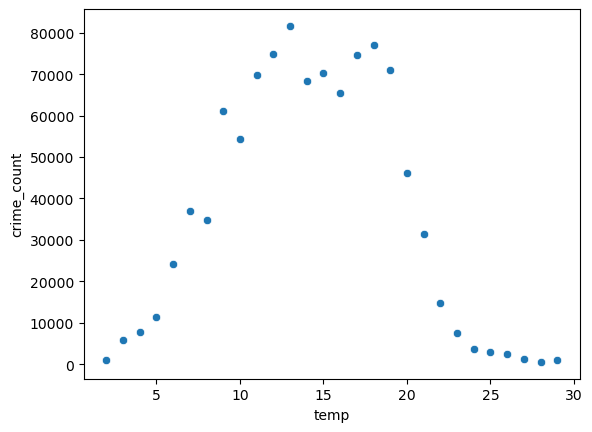

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=crime_by_temp, x='temp', y='crime_count')